Baseline ZM predictions: 253
Soft ZM predictions: 253
Matching ZM predictions: 253


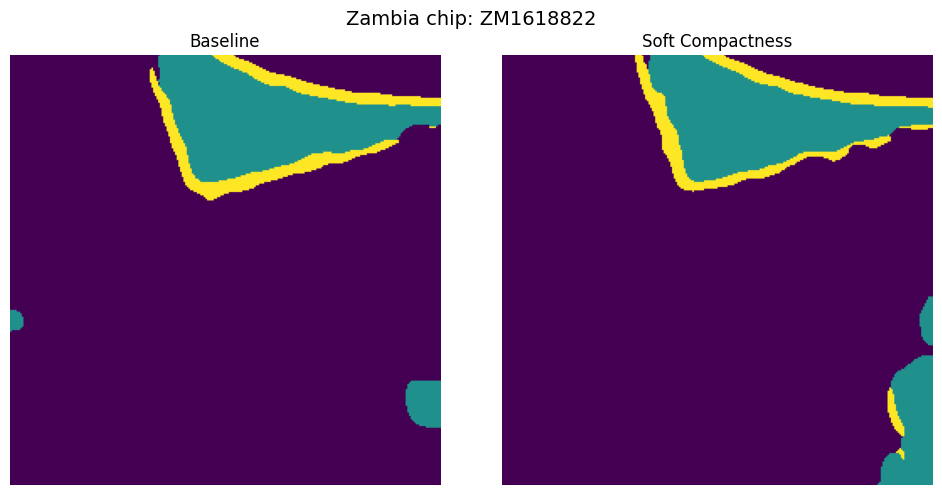

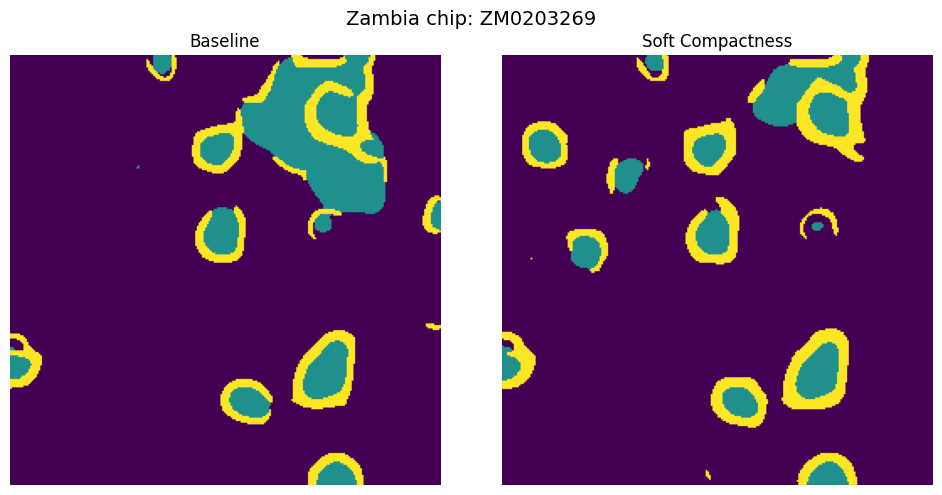

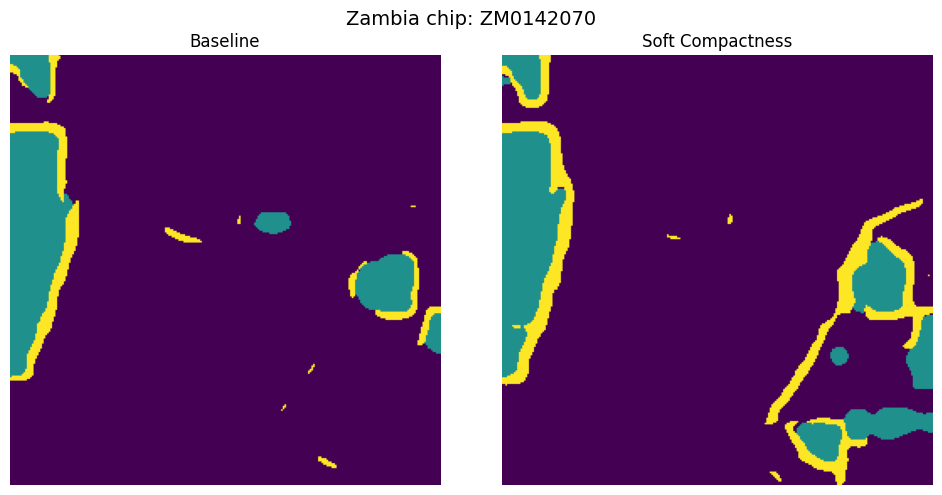

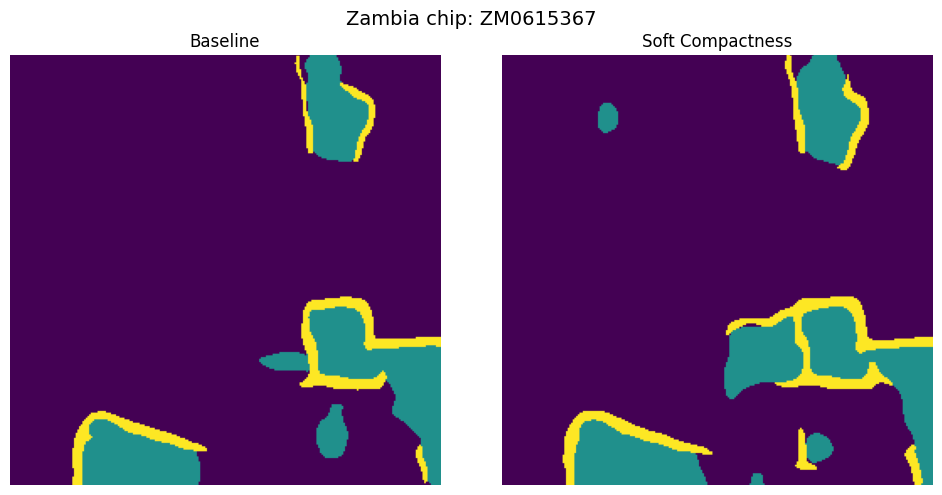

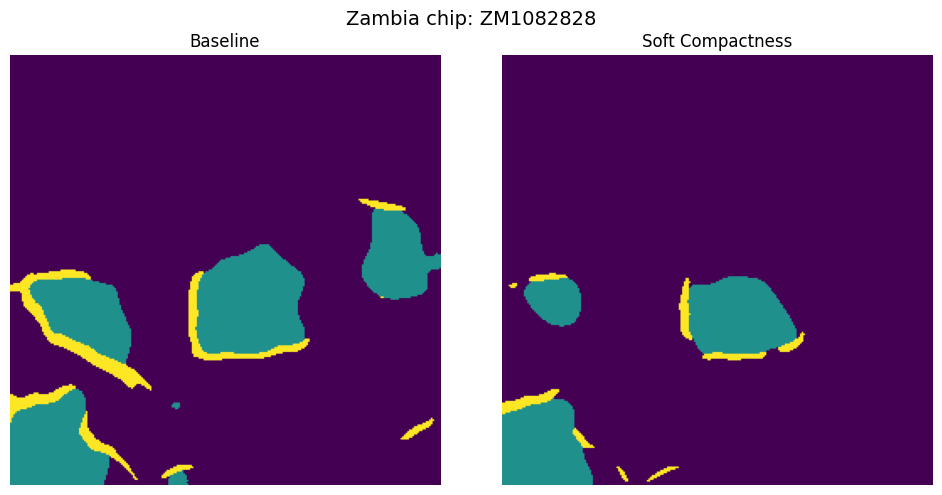

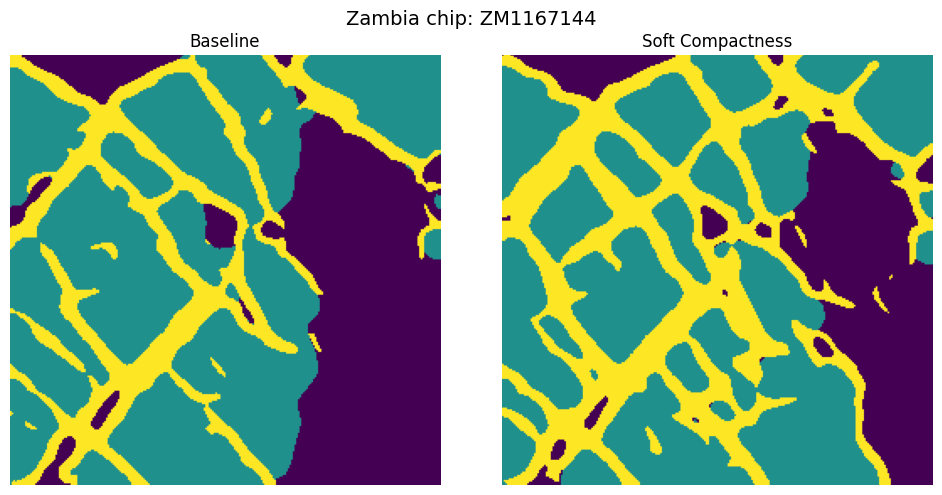

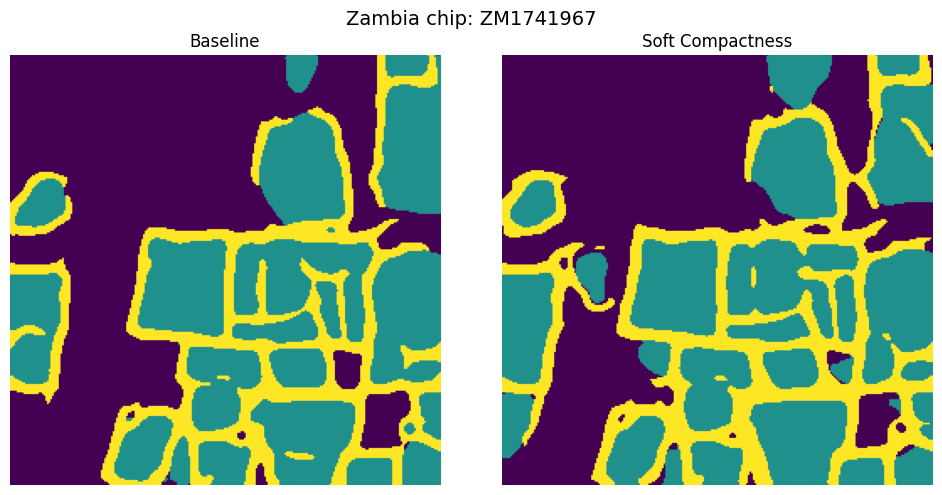

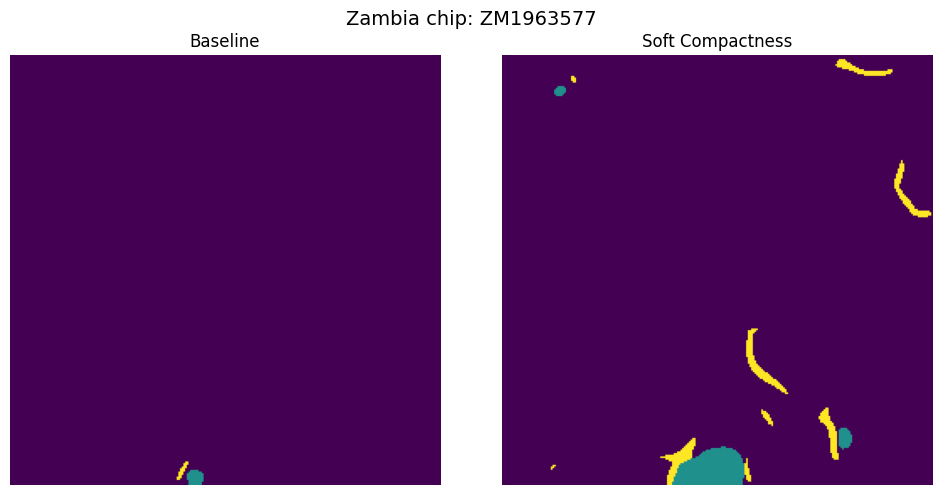

Saved 8 plots to: /opt/app-root/src/working/models/outputs/comparison_plots/zm_random8


In [6]:
from pathlib import Path
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt

BASELINE_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/baseline_5k/version_2/baseline_5k")
SOFT_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/softcompactness_5k/version_2/softcompactness_5k")

OUT_DIR = Path("/opt/app-root/src/working/models/outputs/comparison_plots/zm_random8")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N = 8
# SEED = 42

def read_band(path):
    with rasterio.open(path) as src:
        return src.read(1)

# Get prediction files
baseline_files = {
    p.stem.replace("_prediction", ""): p
    for p in BASELINE_DIR.glob("ZM*_prediction.tif")
}

soft_files = {
    p.stem.replace("_prediction", ""): p
    for p in SOFT_DIR.glob("ZM*_prediction.tif")
}

# Keep only chips present in both folders
common_ids = sorted(set(baseline_files) & set(soft_files))

print("Baseline ZM predictions:", len(baseline_files))
print("Soft ZM predictions:", len(soft_files))
print("Matching ZM predictions:", len(common_ids))

if len(common_ids) == 0:
    raise ValueError("No matching ZM prediction files found.")

# random.seed(SEED)
sample_ids = random.sample(common_ids, min(N, len(common_ids)))

for chip_id in sample_ids:
    baseline = read_band(baseline_files[chip_id])
    soft = read_band(soft_files[chip_id])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(baseline, vmin=0, vmax=2)
    axes[0].set_title("Baseline")

    axes[1].imshow(soft, vmin=0, vmax=2)
    axes[1].set_title("Soft Compactness")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(f"Zambia chip: {chip_id}", fontsize=14)
    plt.tight_layout()

    out_path = OUT_DIR / f"{chip_id}_baseline_vs_softcompactness.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Saved {len(sample_ids)} plots to: {OUT_DIR}")

In [1]:
from pathlib import Path
import geopandas as gpd
from tqdm import tqdm

# If makeinstances.py is in the instancemaker repo:
import sys
sys.path.append("/opt/app-root/src/gregg-work/instancemaker/src")

from instancemaker.makeinstances import MakeInstances

# -----------------------------
# Paths
# -----------------------------
BASELINE_PRED_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/baseline_5k/version_2/baseline_5k")
SOFT_PRED_DIR = Path("/opt/app-root/src/working/models/outputs/predictions/softcompactness_5k/version_2/softcompactness_5k")

BASELINE_OUT_DIR = Path("/opt/app-root/src/working/instances_direct/baseline_polygons")
SOFT_OUT_DIR = Path("/opt/app-root/src/working/instances_direct/soft_polygons")

BASELINE_OUT_DIR.mkdir(parents=True, exist_ok=True)
SOFT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# MakeInstances object
# -----------------------------
mki = MakeInstances(
    kernel=[
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
    ],
    threshold_type="class",
    class_id=1,
    threshold=0,
    erosion_iterations=0,
    dilation_iterations=0,
)

# -----------------------------
# Polygonize function
# -----------------------------
def polygonize_prediction_folder(pred_dir, out_dir, simplify=0):
    pred_files = sorted(pred_dir.glob("ZM*_prediction.tif"))

    print("Prediction files found:", len(pred_files))
    print("Output folder:", out_dir)

    all_records = []

    for pred_path in tqdm(pred_files):
        chip_id = pred_path.stem.replace("_prediction", "")
        out_path = out_dir / f"{chip_id}_polygons.geojson"

        try:
            gdf = mki.polygonize(
                image=str(pred_path),
                simplify=simplify,
                labeled=False,
                erode_dilate=False,
                polygon_filename=str(out_path),
            )

            gdf["chip_id"] = chip_id
            gdf["source_prediction"] = pred_path.name
            gdf["n_polygons_tile"] = len(gdf)

            all_records.append(gdf)

        except Exception as e:
            print(f"Failed: {pred_path.name}")
            print(e)

    if all_records:
        merged = gpd.GeoDataFrame(
            pd.concat(all_records, ignore_index=True),
            crs=all_records[0].crs
        )
        return merged

    return gpd.GeoDataFrame()


# -----------------------------
# Run baseline + soft compactness
# -----------------------------
import pandas as pd

baseline_gdf = polygonize_prediction_folder(
    BASELINE_PRED_DIR,
    BASELINE_OUT_DIR,
    simplify=0
)

soft_gdf = polygonize_prediction_folder(
    SOFT_PRED_DIR,
    SOFT_OUT_DIR,
    simplify=0
)

print("Baseline polygons:", len(baseline_gdf))
print("Soft compactness polygons:", len(soft_gdf))

Prediction files found: 253
Output folder: /opt/app-root/src/working/instances_direct/baseline_polygons


100%|██████████| 253/253 [00:06<00:00, 37.72it/s]


Prediction files found: 253
Output folder: /opt/app-root/src/working/instances_direct/soft_polygons


100%|██████████| 253/253 [00:05<00:00, 49.00it/s]

Baseline polygons: 3136
Soft compactness polygons: 2788


In [2]:
BASELINE_COMBINED = Path("/opt/app-root/src/working/instances_direct/baseline_all_polygons.gpkg")
SOFT_COMBINED = Path("/opt/app-root/src/working/instances_direct/soft_all_polygons.gpkg")

baseline_gdf.to_file(BASELINE_COMBINED, driver="GPKG")
soft_gdf.to_file(SOFT_COMBINED, driver="GPKG")

print(BASELINE_COMBINED)
print(SOFT_COMBINED)

/opt/app-root/src/working/instances_direct/baseline_all_polygons.gpkg
/opt/app-root/src/working/instances_direct/soft_all_polygons.gpkg


In [3]:
import numpy as np

def compute_shape_metrics(gdf):
    gdf = gdf.copy()

    # Ensure projected CRS (you already set ESRI:102022 earlier)
    gdf = gdf.to_crs("ESRI:102022")

    # Basic geometry
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length

    # -------------------------
    # Shape metrics
    # -------------------------

    # 1. Compactness (Polsby-Popper)
    gdf["compactness"] = (4 * np.pi * gdf["area"]) / (gdf["perimeter"] ** 2)

    # 2. Convexity
    gdf["convex_area"] = gdf.geometry.convex_hull.area
    gdf["convexity"] = gdf["area"] / gdf["convex_area"]

    # 3. Rectangularity
    gdf["bbox_area"] = gdf.geometry.envelope.area
    gdf["rectangularity"] = gdf["area"] / gdf["bbox_area"]

    # 4. Elongation (based on bounding box)
    bounds = gdf.geometry.bounds
    width = bounds["maxx"] - bounds["minx"]
    height = bounds["maxy"] - bounds["miny"]

    gdf["elongation"] = np.maximum(width, height) / np.minimum(width, height)

    return gdf

In [4]:
baseline_metrics = compute_shape_metrics(baseline_gdf)
soft_metrics = compute_shape_metrics(soft_gdf)

print("Baseline polygons:", len(baseline_metrics))
print("Soft polygons:", len(soft_metrics))

Baseline polygons: 3136
Soft polygons: 2788


In [ ]:
def summarize_metrics(name, gdf):
    print(f"\n{name} SUMMARY")
    print("-" * 30)
    print("Mean area:", gdf["area"].mean())
    print("Mean compactness:", gdf["compactness"].mean())
    print("Mean convexity:", gdf["convexity"].mean())
    print("Mean rectangularity:", gdf["rectangularity"].mean())
    print("Mean elongation:", gdf["elongation"].mean())

summarize_metrics("BASELINE", baseline_metrics)
summarize_metrics("SOFT COMPACTNESS", soft_metrics)

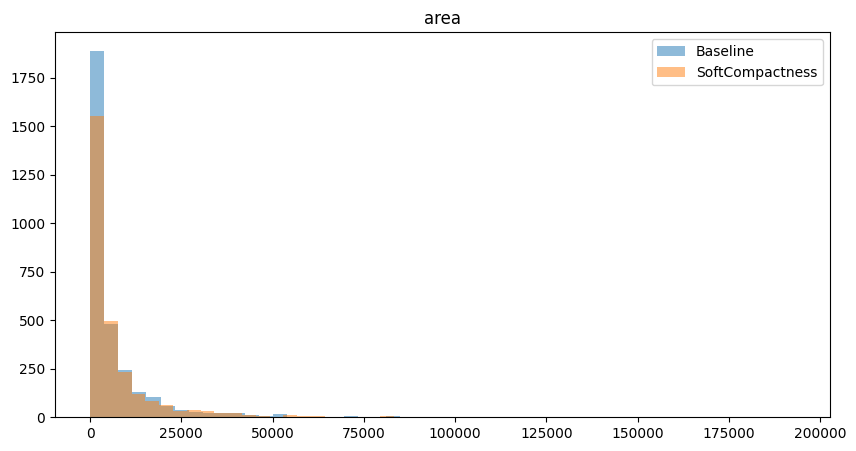

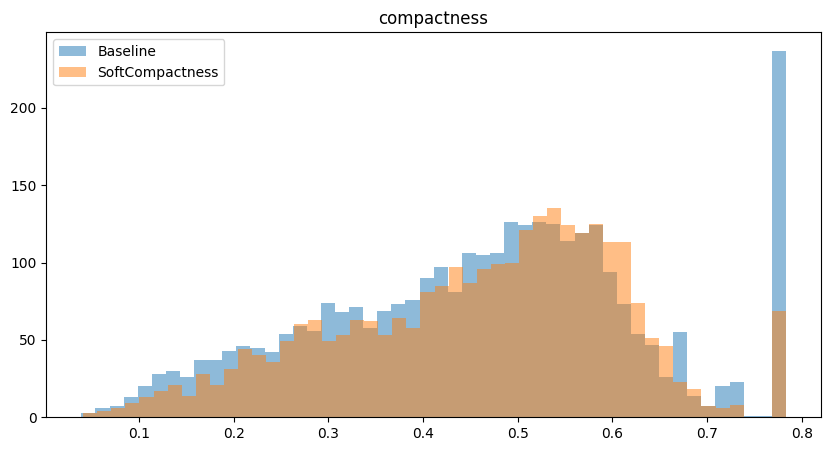

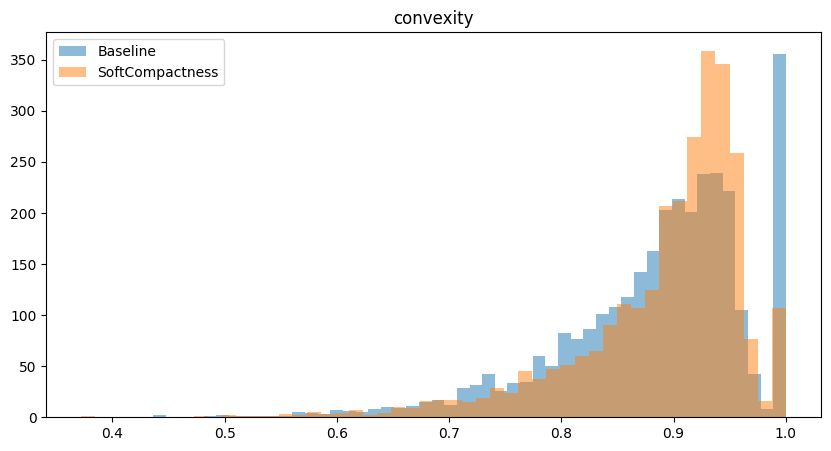

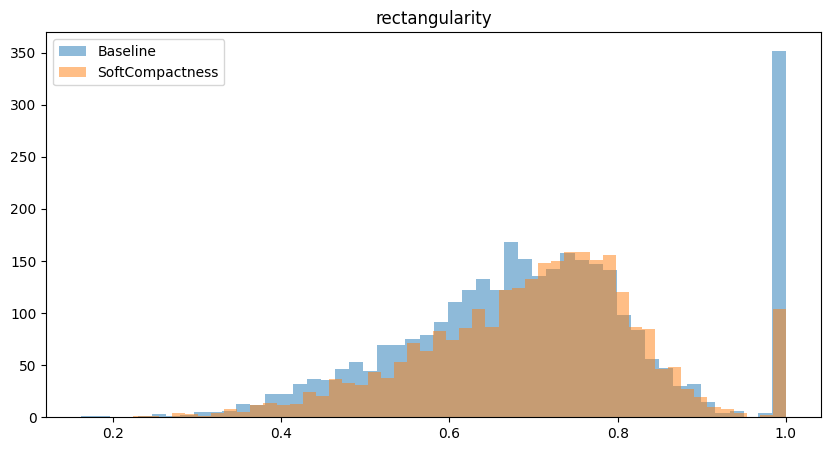

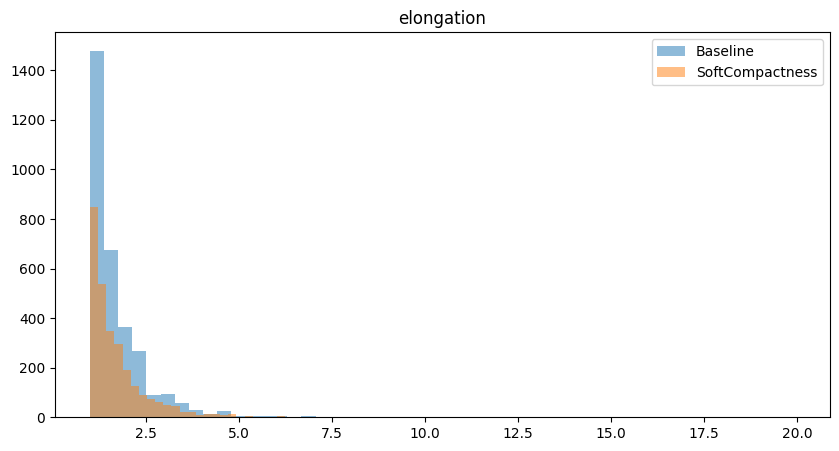

In [5]:
import matplotlib.pyplot as plt

def plot_hist(metric):
    plt.figure(figsize=(10,5))

    plt.hist(baseline_metrics[metric], bins=50, alpha=0.5, label="Baseline")
    plt.hist(soft_metrics[metric], bins=50, alpha=0.5, label="SoftCompactness")

    plt.title(metric)
    plt.legend()
    plt.show()

for m in ["area", "compactness", "convexity", "rectangularity", "elongation"]:
    plot_hist(m)